# Дискретне косинусне перетворення

In [26]:
import numpy as np
PI2 = np.pi * 2

### Синтез

Синтезувати багаточастотний сигнал досить просто: створюємо синсоїдальні сигнали потрібних частот та амплітуд і обчислюємо їх суму.

In [27]:
from thinkdsp import CosSignal, SumSignal

def synthesize1(amps, fs, ts):
    components = [CosSignal(freq, amp)
                  for amp, freq in zip(amps, fs)]
    signal = SumSignal(*components)

    ys = signal.evaluate(ts)
    return ys

Наприклад, утворимо сигнал з чотирьох синусоїд

In [28]:
from thinkdsp import Wave

amps = np.array([0.6, 0.25, 0.1, 0.05])
fs = [100, 200, 300, 400]
framerate = 11025

ts = np.linspace(0, 1, framerate, endpoint=False)
ys = synthesize1(amps, fs, ts)
wave = Wave(ys, ts, framerate)
wave.apodize()
wave.make_audio()

Заглянемо "під капот" методів ThinkDSP і спробуємо синтезувати синал без їх прямого застосування

In [29]:
def synthesize2(amps, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    ys = np.dot(M, amps)
    return ys

Переконаємось, що результат звучить так само:

In [30]:
ys = synthesize2(amps, fs, ts)
wave = Wave(ys, framerate)
wave.apodize()
wave.make_audio()

Переконаємось, що різниця між сигналами, що утворені різними способами, лежить в межах похибок обчислень

In [31]:
ys1 = synthesize1(amps, fs, ts)
ys2 = synthesize2(amps, fs, ts)
np.max(np.abs(ys1 - ys2))

1.2789769243681803e-13

### Аналіз

Найпростіший спосіб аналізу сигналу, тобто знаходження амплітуди для кожного компонента, полягає у створенні такої ж матриці, яку ми використовували для синтезу, а потім у розв'язанні системи лінійних рівнянь.

In [32]:
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

Використовуючи перші 4 значення з хвильового масиву, ми можемо відновити амплітуди.

In [33]:
n = len(fs)
amps2 = analyze1(ys[:n], fs, ts[:n])
amps2

array([0.6 , 0.25, 0.1 , 0.05])

Поки що ми маємо просту версію дискретного косинусного перетворення (DCT), але це неефективна реалізація, оскільки отримана нами матриця не є ортогональною.

In [34]:
# suppress scientific notation for small numbers
np.set_printoptions(precision=3, suppress=True)

In [35]:
def test1():
    N = 4.0
    time_unit = 0.001
    ts = np.arange(N) / N * time_unit
    max_freq = N / time_unit / 2
    fs = np.arange(N) / N * max_freq
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    return M

M = test1()
M

array([[ 1.   ,  1.   ,  1.   ,  1.   ],
       [ 1.   ,  0.707,  0.   , -0.707],
       [ 1.   ,  0.   , -1.   , -0.   ],
       [ 1.   , -0.707, -0.   ,  0.707]])

Щоб перевірити, чи є матриця ортогональною, ми можемо обчислити $M^T M$, що має дати в результаті одиничну матрицю:

In [36]:
M.transpose().dot(M)

array([[ 4.,  1., -0.,  1.],
       [ 1.,  2.,  1.,  0.],
       [-0.,  1.,  2.,  1.],
       [ 1.,  0.,  1.,  2.]])

Але це не так, а це означає, що матриця $M$ не є ортогональною.

Розв'язання лінійної системи із загальною матрицею (тобто такою, що не має таких приємних властивостей, як ортогональність) займає час, пропорційний $N^3$. З ортогональною матрицею ми можемо отримати це значення до $N^2$. Ось як:

In [37]:
def test2():
    N = 4.0
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    return M
    
M = test2()
M

array([[ 0.981,  0.831,  0.556,  0.195],
       [ 0.831, -0.195, -0.981, -0.556],
       [ 0.556, -0.981,  0.195,  0.831],
       [ 0.195, -0.556,  0.831, -0.981]])

Тепер $M^T M$ дорівнює $2I$ (приблизно), отже M є майже ортогональною, за винятком коефіцієнта 2.

In [38]:
M.transpose().dot(M)

array([[ 2., -0.,  0.,  0.],
       [-0.,  2., -0., -0.],
       [ 0., -0.,  2., -0.],
       [ 0., -0., -0.,  2.]])

А це означає, що ми можемо вирішити задачу аналізу за допомогою множення матриць.

In [39]:
def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = M.dot(ys) / 2
    return amps

Це працює:

In [40]:
n = len(fs)
amps2 = analyze1(ys[:n], fs, ts[:n])
amps2

array([0.6 , 0.25, 0.1 , 0.05])

### DCT

Ми реалізували DCT-IV, одну з кількох версій DCT, що використовують ортогональні матриці.

In [41]:
def dct_iv(ys):
    N = len(ys)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

Перевіримо, як це працює:

In [42]:
amps = np.array([0.6, 0.25, 0.1, 0.05])
N = 4.0
ts = (0.5 + np.arange(N)) / N
fs = (0.5 + np.arange(N)) / 2
ys = synthesize2(amps, fs, ts)

amps2 = dct_iv(ys)
np.max(np.abs(amps - amps2))

8.326672684688674e-17

DCT та обернене DCT — це одне й те саме, за винятком коефіцієнта 2.

In [43]:
def inverse_dct_iv(amps):
    return dct_iv(amps) * 2

І це працює:

In [44]:
amps = [0.6, 0.25, 0.1, 0.05]
ys = inverse_dct_iv(amps)
amps2 = dct_iv(ys)
np.max(np.abs(amps - amps2))

8.326672684688674e-17

`thinkdsp` надає клас `Dct`, який інкапсулює DCT так само, як клас Spectrum інкапсулює FFT.

In [45]:
from thinkdsp import TriangleSignal

signal = TriangleSignal(freq=400)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.make_audio()

Щоб створити об'єкт Dct, можна викликати метод `make_dct` для об'єкта типу 'Wave'.

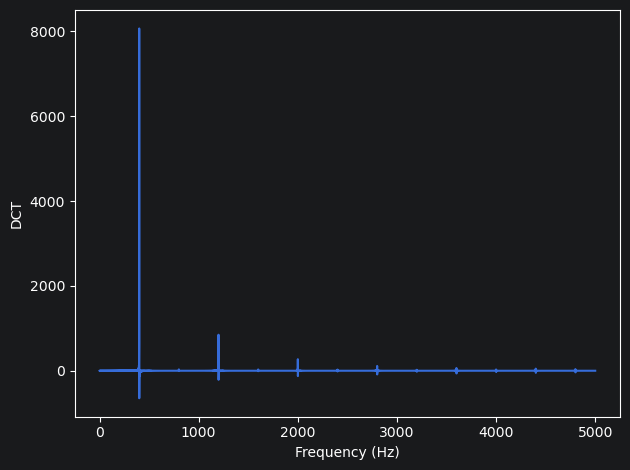

In [46]:
from thinkdsp import decorate

dct = wave.make_dct()
dct.plot()
decorate(xlabel='Frequency (Hz)', ylabel='DCT')

`Dct` надає метод `make_wave`, який виконує інверсне DCT.

In [47]:
wave2 = dct.make_wave()

Результат дуже близький до хвилі, з якої ми починали.

In [48]:
np.max(np.abs(wave.ys-wave2.ys))

7.771561172376096e-16

Обернення знаку сигналу змінює знак DCT.

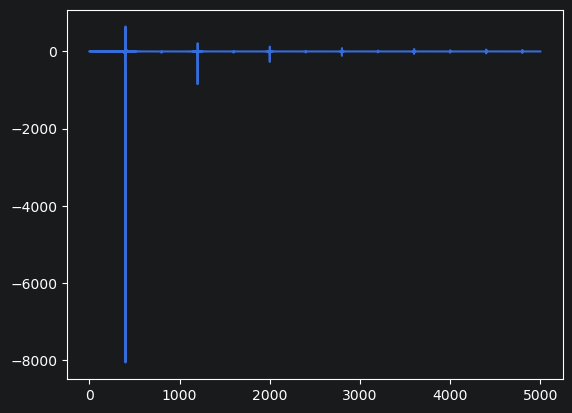

In [49]:
signal = TriangleSignal(freq=400, offset=0)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.ys *= -1
wave.make_dct().plot()

Додавання фазового зсуву $\phi=\pi$ має той самий ефект.

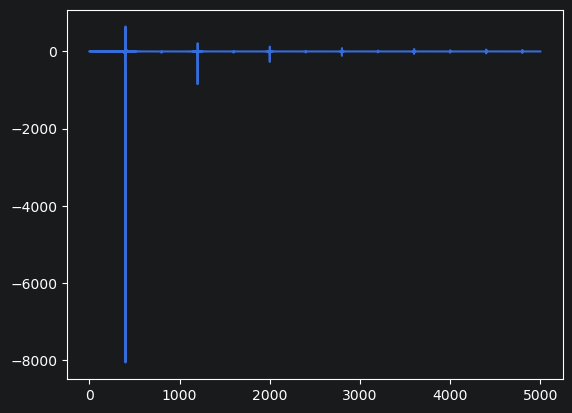

In [50]:
signal = TriangleSignal(freq=400, offset=np.pi)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.make_dct().plot()